In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score, recall_score

In [38]:
y_test = ['A', 'B', 'B', 'A', 'B', 'A']
y_pred = ['B', 'B', 'A', 'A', 'A', 'B']

In [52]:
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

In [ ]:
df

In [54]:
df = pd.get_dummies(df,drop_first= True)

In [ ]:
df

In [24]:
confusion_matrix = confusion_matrix(df['Actual'], df['Predicted'])

In [ ]:
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')

In [ ]:
TP = confusion_matrix[0][0]
TN = confusion_matrix[1][1]
FP = confusion_matrix[0][1]
FN = confusion_matrix[1][0]
print(TP, TN, FP, FN)

In [ ]:
accuracy = (TP + TN) / np.sum(confusion_matrix)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


In [61]:
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred, pos_label='B'))
print(precision_score(y_test, y_pred, pos_label='B'))


0.3333333333333333
0.3333333333333333
0.3333333333333333


In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.33      0.33      0.33         3
           B       0.33      0.33      0.33         3

    accuracy                           0.33         6
   macro avg       0.33      0.33      0.33         6
weighted avg       0.33      0.33      0.33         6



In [3]:
df = pd.read_csv("Datasets/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
y= df['Outcome']

In [6]:
x= df.drop('Outcome', axis=1)

In [7]:
k = 15

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [9]:
model = LinearRegression()
model.fit(x_train,y_train)
pred = model.predict(x_test)

In [10]:
pred

array([ 0.33644062,  0.24424301,  0.14520959,  0.21833941,  0.48808641,
        0.46203718, -0.18497507,  0.56741264,  0.5399926 ,  0.71287154,
        0.32593566,  0.88017751,  0.40867684,  0.34059688,  0.0797864 ,
        0.40725375,  0.17496092,  0.07259416,  0.79869052,  0.51907446,
        0.27951871,  0.08469941,  0.51478926,  0.11379765,  0.52114077,
        0.84264031,  0.1777638 , -0.0538857 ,  0.29606542,  0.15675906,
        0.84772146,  0.80681529,  0.71505812,  0.73678726,  0.54674781,
        0.62167511,  1.096693  ,  0.30367217,  0.5201481 ,  0.61401386,
        0.06325415,  0.56756723,  0.54657596,  0.35705635, -0.07781953,
        0.51174592,  0.58434125,  0.26889393,  0.40600432,  1.00283423,
        0.00769032,  0.6264228 ,  0.75349877,  0.30217301,  0.15145682,
       -0.03092717,  0.72121004, -0.32853224,  0.41018576,  0.68607264,
        0.67634715,  0.38055482,  0.31285439,  0.26848731,  0.07505618,
        0.57083719,  0.00502562,  0.63374793, -0.03014603,  0.67

In [11]:
KNN = KNeighborsClassifier(n_neighbors=k)

In [12]:
KNN.fit(x_train,y_train)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
y_pred = KNN.predict(x_test)

In [15]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [16]:
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

In [17]:
df

,Actual,Predicted
668,0,0
324,0,0
624,0,0
690,0,0
473,0,0
...,...,...
554,0,0
319,1,1
594,0,0
6,1,0


In [18]:
conf_matrix = confusion_matrix(df['Actual'], df['Predicted'])

In [19]:
conf_matrix

array([[104,  19],
       [ 31,  38]])

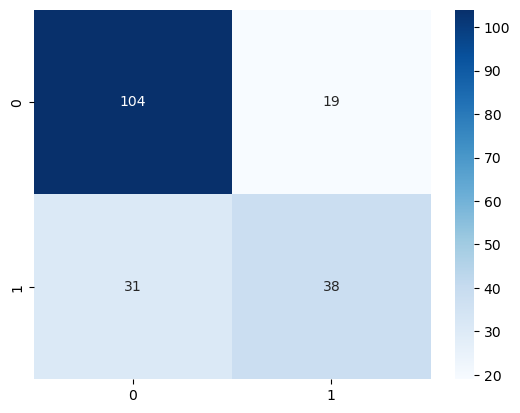

In [21]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.show()

In [ ]:
accuracy = accuracy_score(df['Actual'], df['Predicted'])
precision = precision_score(df['Actual'], df['Predicted'])
recall = recall_score(df['Actual'], df['Predicted'])

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       123
           1       0.67      0.55      0.60        69

    accuracy                           0.74       192
   macro avg       0.72      0.70      0.70       192
weighted avg       0.73      0.74      0.73       192

